# Emotion Classification with RoBERTa

Fine-tunes `distilroberta-base` on the Hugging Face `emotion` dataset for 6-class emotion classification.

| Requirement | Choice |
|---|---|
| **Task** | Multi-class emotion classification |
| **Domain** | Short social-media-style text (Hugging Face `emotion` dataset) |
| **LLM** | `distilroberta-base` (RoBERTa-based sequence classifier) |
| **Config** | 80/20 split · lr=2e-5 · batch=16 · 3 epochs · weight decay=0.01 |
| **Evaluation** | Accuracy, weighted F1, per-class F1, confusion matrix |

In [1]:
import gc
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from datasets import load_dataset
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)  

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [2]:
# ── 1. Load dataset and derive label mappings from the data itself ────────────
raw = load_dataset("emotion")
split = raw["train"].train_test_split(test_size=0.2, seed=SEED)
train_dataset = split["train"]
valid_dataset = split["test"]

label_feature = train_dataset.features["label"]
id2label = {i: label_feature.int2str(i) for i in range(label_feature.num_classes)}
label2id = {v: k for k, v in id2label.items()}
num_labels = len(id2label)

print("Labels:", id2label)
print(f"Train samples: {len(train_dataset)} | Valid samples: {len(valid_dataset)}")

from collections import Counter
train_counts = Counter(train_dataset["label"])
print("\nClass distribution (train):")
for idx, count in sorted(train_counts.items()):
    print(f"  {id2label[idx]:10s}: {count:5d} ({count/len(train_dataset)*100:.1f}%)")

Labels: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Train samples: 12800 | Valid samples: 3200

Class distribution (train):
  sadness   :  3742 (29.2%)
  joy       :  4266 (33.3%)
  love      :  1055 (8.2%)
  anger     :  1743 (13.6%)
  fear      :  1537 (12.0%)
  surprise  :   457 (3.6%)


In [3]:
# ── 2. Tokenize ───────────────────────────────────────────────────────────────
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "right"

def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_dataset = train_dataset.map(tokenize_fn, batched=True).remove_columns(["text"])
valid_dataset = valid_dataset.map(tokenize_fn, batched=True).remove_columns(["text"])
train_dataset.set_format("torch")
valid_dataset.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete.")

Tokenization complete.


c:\Users\melis\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [4]:
# ── 3. Load model ─────────────────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params: 82,123,014 | Trainable: 82,123,014


In [5]:
# ── 4. Training configuration ─────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro"),  
    }

use_gpu = DEVICE.type == "cuda"

training_args = TrainingArguments(
    output_dir="./emotion-distilroberta-base-output",
    seed=SEED,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,           
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    fp16=use_gpu,                
    use_cpu=not use_gpu,
    dataloader_pin_memory=use_gpu,
    dataloader_num_workers=0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer ready.")

Trainer ready.


In [6]:
# ── 5. Fine-tune ──────────────────────────────────────────────────────────────
trainer.train()
print("Training complete.")

  0%|          | 0/2400 [00:00<?, ?it/s]

{'loss': 1.846, 'grad_norm': 3.8824400901794434, 'learning_rate': 4.166666666666667e-06, 'epoch': 0.06}
{'loss': 1.6624, 'grad_norm': 7.425293445587158, 'learning_rate': 8.333333333333334e-06, 'epoch': 0.12}
{'loss': 1.3404, 'grad_norm': 6.712625503540039, 'learning_rate': 1.25e-05, 'epoch': 0.19}
{'loss': 1.2039, 'grad_norm': 10.22722053527832, 'learning_rate': 1.6666666666666667e-05, 'epoch': 0.25}
{'loss': 1.017, 'grad_norm': 8.978619575500488, 'learning_rate': 1.990740740740741e-05, 'epoch': 0.31}
{'loss': 0.699, 'grad_norm': 11.0631103515625, 'learning_rate': 1.9444444444444445e-05, 'epoch': 0.38}
{'loss': 0.611, 'grad_norm': 10.285706520080566, 'learning_rate': 1.8981481481481482e-05, 'epoch': 0.44}
{'loss': 0.4974, 'grad_norm': 13.497952461242676, 'learning_rate': 1.851851851851852e-05, 'epoch': 0.5}
{'loss': 0.4276, 'grad_norm': 17.892763137817383, 'learning_rate': 1.8055555555555558e-05, 'epoch': 0.56}
{'loss': 0.4165, 'grad_norm': 31.68299674987793, 'learning_rate': 1.7592592

  0%|          | 0/200 [00:00<?, ?it/s]

{'eval_loss': 0.28855013847351074, 'eval_accuracy': 0.898125, 'eval_f1_weighted': 0.8978833170316141, 'eval_f1_macro': 0.8635943261300393, 'eval_runtime': 111.0477, 'eval_samples_per_second': 28.816, 'eval_steps_per_second': 1.801, 'epoch': 1.0}
{'loss': 0.2548, 'grad_norm': 14.28931999206543, 'learning_rate': 1.4351851851851853e-05, 'epoch': 1.06}
{'loss': 0.2494, 'grad_norm': 14.184664726257324, 'learning_rate': 1.388888888888889e-05, 'epoch': 1.12}
{'loss': 0.2446, 'grad_norm': 28.808244705200195, 'learning_rate': 1.3425925925925926e-05, 'epoch': 1.19}
{'loss': 0.1657, 'grad_norm': 11.929713249206543, 'learning_rate': 1.2962962962962964e-05, 'epoch': 1.25}
{'loss': 0.1815, 'grad_norm': 12.864034652709961, 'learning_rate': 1.25e-05, 'epoch': 1.31}
{'loss': 0.2415, 'grad_norm': 25.342369079589844, 'learning_rate': 1.2037037037037039e-05, 'epoch': 1.38}
{'loss': 0.2398, 'grad_norm': 12.708083152770996, 'learning_rate': 1.1574074074074075e-05, 'epoch': 1.44}
{'loss': 0.199, 'grad_norm':

  0%|          | 0/200 [00:00<?, ?it/s]

{'eval_loss': 0.24138770997524261, 'eval_accuracy': 0.9125, 'eval_f1_weighted': 0.9115100559002981, 'eval_f1_macro': 0.8761983562956187, 'eval_runtime': 154.2786, 'eval_samples_per_second': 20.742, 'eval_steps_per_second': 1.296, 'epoch': 2.0}
{'loss': 0.16, 'grad_norm': 13.958625793457031, 'learning_rate': 6.944444444444445e-06, 'epoch': 2.06}
{'loss': 0.1305, 'grad_norm': 5.247894763946533, 'learning_rate': 6.481481481481482e-06, 'epoch': 2.12}
{'loss': 0.139, 'grad_norm': 9.247060775756836, 'learning_rate': 6.018518518518519e-06, 'epoch': 2.19}
{'loss': 0.1398, 'grad_norm': 5.969168186187744, 'learning_rate': 5.555555555555557e-06, 'epoch': 2.25}
{'loss': 0.1444, 'grad_norm': 6.1436052322387695, 'learning_rate': 5.092592592592593e-06, 'epoch': 2.31}
{'loss': 0.1218, 'grad_norm': 2.214003324508667, 'learning_rate': 4.62962962962963e-06, 'epoch': 2.38}
{'loss': 0.1641, 'grad_norm': 19.622957229614258, 'learning_rate': 4.166666666666667e-06, 'epoch': 2.44}
{'loss': 0.1249, 'grad_norm':

  0%|          | 0/200 [00:00<?, ?it/s]

{'eval_loss': 0.22068233788013458, 'eval_accuracy': 0.918125, 'eval_f1_weighted': 0.9181239738874281, 'eval_f1_macro': 0.880864042485101, 'eval_runtime': 43.9361, 'eval_samples_per_second': 72.833, 'eval_steps_per_second': 4.552, 'epoch': 3.0}
{'train_runtime': 6174.6755, 'train_samples_per_second': 6.219, 'train_steps_per_second': 0.389, 'train_loss': 0.3623861859242121, 'epoch': 3.0}
Training complete.


In [7]:
# ── 6. Evaluation ─────────────────────────────────────────────────────────────
metrics = trainer.evaluate(eval_dataset=valid_dataset)
print("\n=== Validation Metrics ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Full per-class breakdown
preds_output = trainer.predict(valid_dataset)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n=== Per-class Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(num_labels)]
))

  0%|          | 0/200 [00:00<?, ?it/s]


=== Validation Metrics ===
  eval_loss: 0.2207
  eval_accuracy: 0.9181
  eval_f1_weighted: 0.9181
  eval_f1_macro: 0.8809
  eval_runtime: 44.9938
  eval_samples_per_second: 71.1210
  eval_steps_per_second: 4.4450
  epoch: 3.0000


  0%|          | 0/200 [00:00<?, ?it/s]


=== Per-class Classification Report ===
              precision    recall  f1-score   support

     sadness       0.95      0.95      0.95       924
         joy       0.95      0.93      0.94      1096
        love       0.78      0.86      0.82       249
       anger       0.91      0.92      0.92       416
        fear       0.85      0.92      0.88       400
    surprise       0.92      0.67      0.77       115

    accuracy                           0.92      3200
   macro avg       0.89      0.88      0.88      3200
weighted avg       0.92      0.92      0.92      3200



C:\Users\melis\AppData\Local\Temp\ipykernel_2236\4053601508.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=20, ha="right")


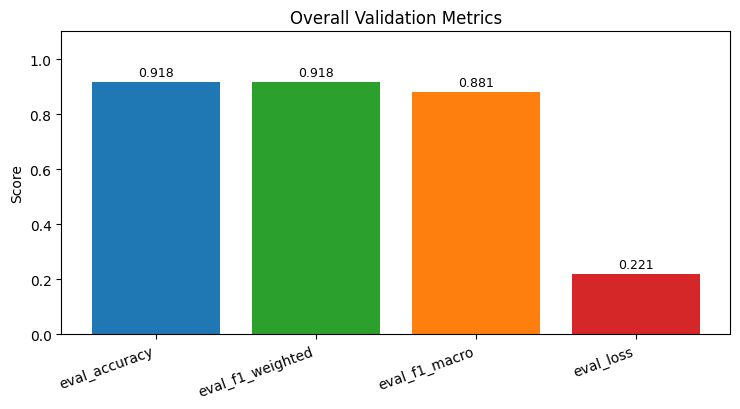

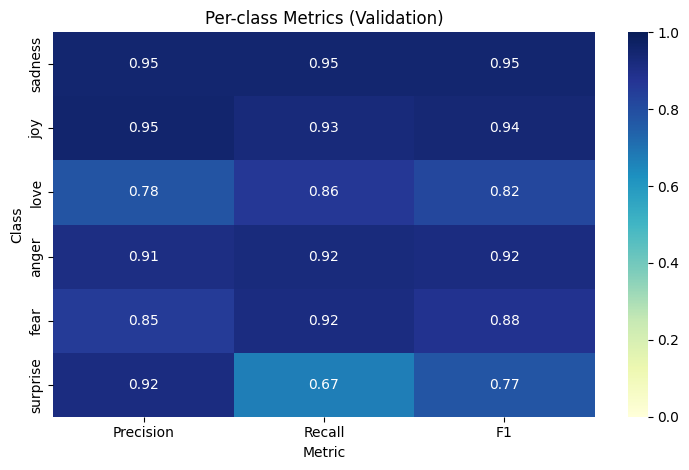

In [8]:
# ── 7. Evaluation metrics visualization ───────────────────────────────────────
label_names = [id2label[i] for i in range(num_labels)]

# Overall evaluation metrics (only plot keys that exist)
overall_metric_keys = ["eval_accuracy", "eval_f1_weighted", "eval_f1_macro", "eval_loss"]
overall_metrics = {k: metrics[k] for k in overall_metric_keys if k in metrics}

if overall_metrics:
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    keys = list(overall_metrics.keys())
    vals = list(overall_metrics.values())
    bars = ax.bar(keys, vals, color=["#1F77B4", "#2CA02C", "#FF7F0E", "#D62728"][: len(keys)])

    ax.set_title("Overall Validation Metrics")
    ax.set_ylim(0, 1.05 if "eval_loss" not in keys else max(vals) * 1.2)
    ax.set_ylabel("Score")
    ax.set_xticklabels(keys, rotation=20, ha="right")

    for bar, value in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

# Per-class Precision/Recall/F1 heatmap
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)

class_metric_matrix = np.array([
    [report_dict[label]["precision"], report_dict[label]["recall"], report_dict[label]["f1-score"]]
    for label in label_names
])

fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.heatmap(
    class_metric_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    xticklabels=["Precision", "Recall", "F1"],
    yticklabels=label_names,
    ax=ax,
)
ax.set_title("Per-class Metrics (Validation)")
ax.set_xlabel("Metric")
ax.set_ylabel("Class")
plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150)
plt.show()

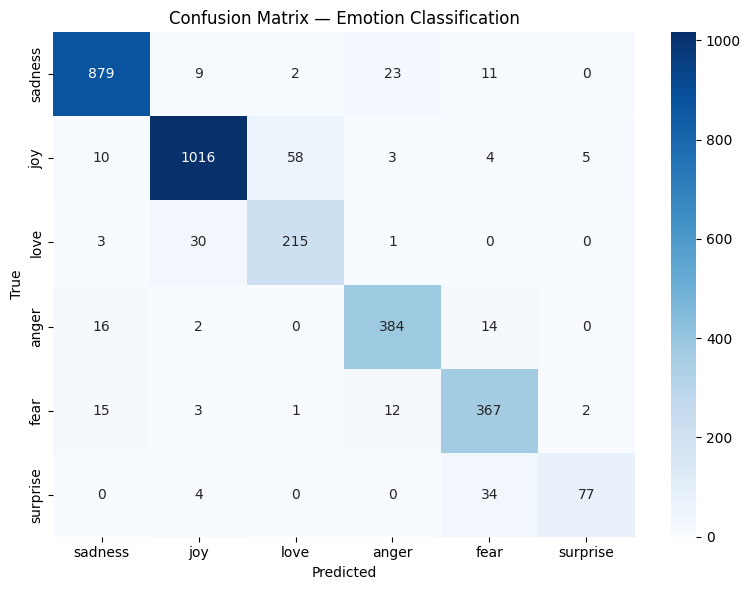

In [9]:
# ── 7. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
label_names = [id2label[i] for i in range(num_labels)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names, yticklabels=label_names, ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Emotion Classification")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## PCA Visualization of Word Embeddings

Extracts token embeddings from the fine-tuned model for 20+ emotionally meaningful words and reduces them to 2D using PCA. Words that are semantically similar should cluster together.

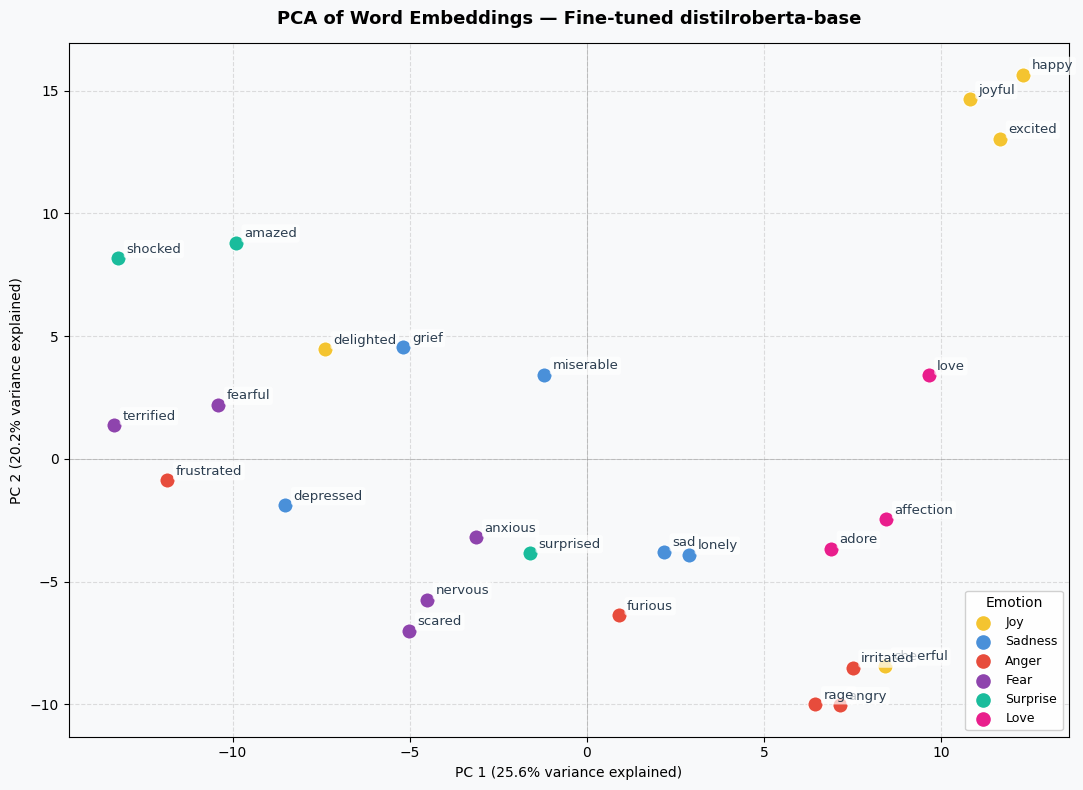

PCA variance explained — PC1: 25.6%  PC2: 20.2%


In [10]:
# ── 10. PCA Visualization of Word Embeddings ─────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

# 20+ emotionally meaningful words spanning all 6 emotion classes
words = [
    # joy
    "happy", "excited", "joyful", "cheerful", "delighted",
    # sadness
    "sad", "depressed", "grief", "miserable", "lonely",
    # anger
    "angry", "furious", "rage", "frustrated", "irritated",
    # fear
    "scared", "fearful", "anxious", "terrified", "nervous",
    # surprise
    "surprised", "shocked", "amazed",
    # love
    "love", "adore", "affection",
]

# Colour + label per emotion group
groups = {
    "joy":      ({"happy", "excited", "joyful", "cheerful", "delighted"},      "#F4C430"),
    "sadness":  ({"sad", "depressed", "grief", "miserable", "lonely"},          "#4A90D9"),
    "anger":    ({"angry", "furious", "rage", "frustrated", "irritated"},       "#E74C3C"),
    "fear":     ({"scared", "fearful", "anxious", "terrified", "nervous"},      "#8E44AD"),
    "surprise": ({"surprised", "shocked", "amazed"},                            "#1ABC9C"),
    "love":     ({"love", "adore", "affection"},                                "#E91E8C"),
}

word_to_group  = {w: g  for g, (ws, _) in groups.items() for w in ws}
word_to_colour = {w: c  for _, (ws, c) in groups.items() for w in ws}

# ── Extract embeddings from the model's base encoder ─────────────────────────
model.eval()
embeddings = []

with torch.no_grad():
    for word in words:
        enc = tokenizer(word, return_tensors="pt").to(DEVICE)
        # roberta: model.roberta  |  distilbert fallback: model.distilbert
        base = getattr(model, "roberta", None) or getattr(model, "distilbert", None)
        hidden = base(**enc).last_hidden_state          # (1, seq_len, hidden)
        # mean-pool over non-padding tokens (all tokens here, seq is short)
        vec = hidden[0].mean(dim=0).cpu().numpy()       # (hidden,)
        embeddings.append(vec)

embeddings = np.array(embeddings)   # (n_words, hidden_size)

# ── PCA → 2D ─────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(embeddings)   # (n_words, 2)
var_explained = pca.explained_variance_ratio_ * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

# Draw points + labels
for i, word in enumerate(words):
    x, y   = coords[i]
    colour = word_to_colour[word]
    ax.scatter(x, y, s=120, color=colour, zorder=3, edgecolors="white", linewidths=0.8)
    ax.annotate(
        word, (x, y),
        textcoords="offset points", xytext=(6, 4),
        fontsize=9.5, color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )

# Legend
for emotion, (_, colour) in groups.items():
    ax.scatter([], [], color=colour, s=90, label=emotion.capitalize())
ax.legend(title="Emotion", title_fontsize=10, fontsize=9,
          loc="lower right", framealpha=0.9)

ax.set_title("PCA of Word Embeddings — Fine-tuned distilroberta-base",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel(f"PC 1 ({var_explained[0]:.1f}% variance explained)", fontsize=10)
ax.set_ylabel(f"PC 2 ({var_explained[1]:.1f}% variance explained)", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("pca_word_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"PCA variance explained — PC1: {var_explained[0]:.1f}%  PC2: {var_explained[1]:.1f}%")


In [11]:
# ── 8. Save model ─────────────────────────────────────────────────────────────
trainer.save_model("./emotion-distilroberta-base-final")
tokenizer.save_pretrained("./emotion-distilroberta-base-final")
print("Model saved to ./emotion-distilroberta-base-final")

Model saved to ./emotion-distilroberta-base-final


In [12]:
# ── 9. Inference demo ─────────────────────────────────────────────────────────
sample_texts = [
    "I feel so happy and excited about today!",
    "I am scared about what might happen next.",
    "This made me really angry and frustrated.",
    "I love spending time with my family.",
    "I can't believe they did that, I'm devastated.",
]

model.eval()
inputs = tokenizer(
    sample_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
).to(DEVICE)  

with torch.no_grad():
    logits = model(**inputs).logits

probs = torch.softmax(logits, dim=-1).cpu().numpy()
preds = np.argmax(probs, axis=-1)

print(f"{'Text':<50} {'Predicted':<12} {'Confidence'}")
print("-" * 75)
for text, pred, prob in zip(sample_texts, preds, probs):
    label = id2label[pred]
    confidence = prob[pred]
    print(f"{text[:48]:<50} {label:<12} {confidence:.2%}")

Text                                               Predicted    Confidence
---------------------------------------------------------------------------
I feel so happy and excited about today!           joy          99.89%
I am scared about what might happen next.          fear         99.81%
This made me really angry and frustrated.          anger        99.37%
I love spending time with my family.               love         62.72%
I can't believe they did that, I'm devastated.     sadness      99.76%
